In [2]:
# install Ultralytics (YOLOv8 library) 
!pip install ultralytics -q 

from ultralytics import YOLO
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba

In [3]:
# Load YOLOv8n (nano - fastest, good for learning) 
model = YOLO('yolov8n.pt')

# run inference on an image
results = model('https://ultralytics.com/images/bus.jpg') 

# Look at the raw results object - understand its structure 
result = results[0] 
print(type(result)) 
print(dir(result)) #explore what's available


image 1/1 /kaggle/working/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 69.3ms
Speed: 9.7ms preprocess, 69.3ms inference, 7.3ms postprocess per image at shape (1, 3, 640, 480)
<class 'ultralytics.engine.results.Results'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_keys', 'boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save', 'save_crop', 'save_dir', 'save_txt', 'semantic_mask', 'show', 'speed', 'summary', 'to', 'to_csv', 'to_df', 'to_json', 'update', 'verbose']


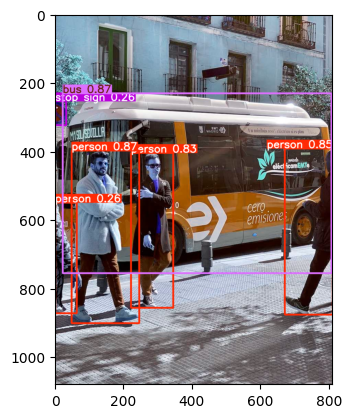

In [4]:
plt.imshow(result.plot()) 

In [5]:
result.summary()

[{'name': 'bus',
  'class': 5,
  'confidence': 0.87345,
  'box': {'x1': 22.87132, 'y1': 231.27727, 'x2': 805.00256, 'y2': 756.84039}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.86569,
  'box': {'x1': 48.55049, 'y1': 398.55219, 'x2': 245.34555, 'y2': 902.7027}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.85284,
  'box': {'x1': 669.4729, 'y1': 392.18613, 'x2': 809.72015, 'y2': 877.03546}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.82522,
  'box': {'x1': 221.51729, 'y1': 405.79865, 'x2': 344.97061, 'y2': 857.53662}},
 {'name': 'person',
  'class': 0,
  'confidence': 0.26111,
  'box': {'x1': 0.0, 'y1': 550.52502, 'x2': 63.00693, 'y2': 873.44293}},
 {'name': 'stop sign',
  'class': 11,
  'confidence': 0.25507,
  'box': {'x1': 0.05816, 'y1': 254.4594, 'x2': 32.55741, 'y2': 324.87415}}]

In [6]:
# The boxes object contains everything 

boxes = result.boxes 
boxes.xyxy  #x1y1 x2y2 coordinates 

tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02],
        [5.8164e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02]], device='cuda:0')

In [7]:
# confidence scores per detection 
print("Confidence scores: \n", boxes.conf) 

# Which class was detected 
print("class indices:\n", boxes.cls)

# index --> class name mapping 
print("Class names:", result.names) 

# How many objects detected 

print(f"\nDetected {len(boxes)} objects")

Confidence scores: 
 tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551], device='cuda:0')
class indices:
 tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
Class names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'ch

In [8]:
x1,y1, x2, y2 = map(int, boxes.xyxy[0])
x1

22

In [9]:
result.names[0]

'person'

In [10]:
def visualize_detections(img_path, results, conf_threshold = 0.5):
    """
    Takes an image path and YOLO results,
    draws bounding boxes and returns annotated image.
    """
    # Read the image. 
    img = cv2.imread(img_path)
    if img is None:
        import urllib.request 
        urllib.request.urlretrieve(img_path, 'temp.jpg')
        img = cv2.imread('temp.jpg')
    result = results[0]
    boxes = result.boxes 
    names = result.names 

    for i in range(len(boxes)):
        conf = boxes.conf[i].item()
        if conf < conf_threshold:
            continue 

        # Get coordinates and convert to integers
        x1,y1,x2,y2 = map(int, boxes.xyxy[i]) 
        cls_idx = boxes.cls[i].item() 
        cls_name = names[cls_idx] 

        # Draw bounding box 
        cv2.rectangle(img, (x1,y1), (x2, y2), color = (0, 255, 0), thickness=2)

        label = f"{cls_name}: {conf:.2f}" 

        (w,h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1, 2) 
        # Draw label bg 
        cv2.rectangle(img, (x1, y1 - h- 10), (x1 + w, y1), (0, 255, 0), -1) # -1 = fill with color  

        cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX,0.6 ,(0, 0, 0), 1) 

    # convert from BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb 




Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /kaggle/working/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.8ms
Speed: 2.6ms preprocess, 6.8ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 480)


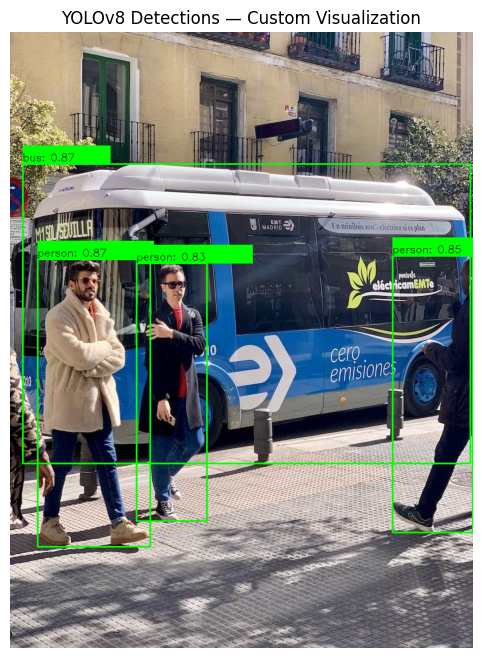

In [11]:
# Test visualisation function. 
image_url = 'https://ultralytics.com/images/bus.jpg'
results = model(image_url)

# Save image locally first for cv2.imread
import urllib.request
urllib.request.urlretrieve(image_url, 'bus.jpg')

annotated = visualize_detections('bus.jpg', results, conf_threshold=0.4)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis('off')
plt.title('YOLOv8 Detections — Custom Visualization')
plt.show()
         


image 1/1 /kaggle/working/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 7.1ms
Speed: 2.2ms preprocess, 7.1ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 480)
  bus             conf=0.873
  person          conf=0.866
  person          conf=0.853
  person          conf=0.825
  person          conf=0.261
  stop sign       conf=0.255


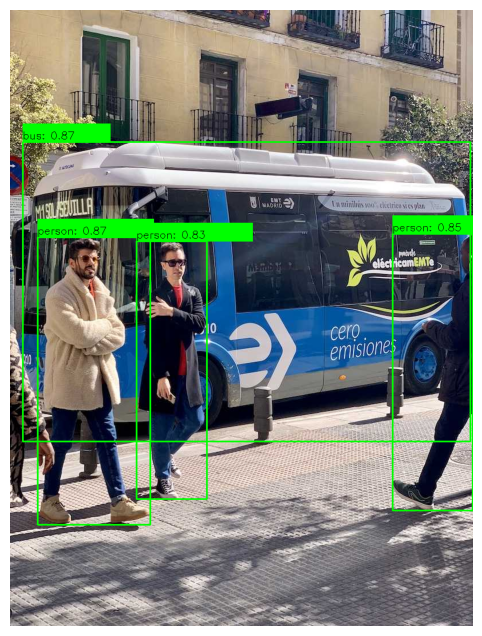

In [20]:
def run_detection(img_path, conf_threshold = .5, model = None):

    if model == None:
        model = YOLO('yolov8n.pt') 

    #run inference 
    results = model(img_path)
    result = results[0]
    boxes = result.boxes
    names = result.names 

    detections = [] 
    
    for i in range(len(boxes)):
        x1,y1,x2,y2 = map(int, boxes.xyxy[i])
        detections.append({
            "class": names[boxes.cls[i].item()], 
            "confidence": boxes.conf[i].item(),
            "bbbx": [x1,y1,x2,y2]
        })

    detections.sort(key = lambda x: x['confidence'], reverse=True) 

    annotated_img = visualize_detections(img_path, results, conf_threshold) 

    return annotated_img, detections 

annotated, detections = run_detection('bus.jpg', conf_threshold=0.4) 

for d in detections:
    print(f"  {d['class']:15s} conf={d['confidence']:.3f}") 

plt.figure(figsize=(12, 8)) 
plt.imshow(annotated)
plt.axis('off') 
plt.show()